# Maxwell Equations, Fourier Transforms, and Optical Propagation

This notebook builds one continuous chain: Maxwell's equations $\to$ the
source-free electromagnetic wave equation $\to$ Fourier-transform derivative
rules $\to$ the plane-wave solution $\to$ Fourier-optics angular-spectrum
propagation, implemented and checked numerically at every step. I teach the
same physical model a MATLAB reference implementation would use; a
NumPy $\leftrightarrow$ MATLAB comparison table is included near the end.

**Conventions used throughout:** SI units; the physics/optics sign
convention $E(\mathbf{r},t)=E_0\,e^{i(\mathbf{k}\cdot\mathbf{r}-\omega t)}$
for traveling waves (the same convention `dgs/gs_core.py` elsewhere in this
repository uses for its dispersion operator). Section 4 below makes the
sign-convention choice explicit and shows the (very common) alternative.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

sp.init_printing()

print(f"numpy {np.__version__}, sympy {sp.__version__}")

numpy 2.4.4, sympy 1.14.0


## 1. Mathematical prerequisites

Six pieces of machinery everything below is built from: complex numbers,
$e^{i\theta}$, vectors, partial derivatives, differential operators, and the
Fourier transform. I first define each symbolically so later derivations
are honest algebra, not assertions.

In [2]:
# -- complex numbers --
a, b, c, d = sp.symbols('a b c d', real=True)
z1 = a + sp.I*b
z2 = c + sp.I*d
product = sp.expand(z1 * z2)
print("Complex multiplication (a+ib)(c+id):")
display(sp.Eq(z1*z2, product))

Complex multiplication (a+ib)(c+id):


In [3]:
# -- exp(i theta) = cos(theta) + i sin(theta) --
theta = sp.Symbol('theta', real=True)
euler_lhs = sp.exp(sp.I * theta)
euler_rhs = sp.cos(theta) + sp.I * sp.sin(theta)
identity_holds = sp.simplify(euler_lhs.rewrite(sp.cos) - euler_rhs) == 0
print(f"Euler's formula verified symbolically: {identity_holds}")
display(sp.Eq(euler_lhs, euler_rhs))

Euler's formula verified symbolically: True


In [4]:
# -- vectors: dot and cross product --
kx, ky, kz, Ex, Ey, Ez = sp.symbols('k_x k_y k_z E_x E_y E_z', real=True)
k_vec = sp.Matrix([kx, ky, kz])
E_vec = sp.Matrix([Ex, Ey, Ez])

dot = k_vec.dot(E_vec)
cross = k_vec.cross(E_vec)
print("k . E =")
display(dot)
print("k x E =")
display(cross)

k . E =


k x E =


⎡-E_y⋅k_z + E_z⋅k_y⎤
⎢                  ⎥
⎢ Eₓ⋅k_z - E_z⋅kₓ  ⎥
⎢                  ⎥
⎣ -Eₓ⋅k_y + E_y⋅kₓ ⎦

In [5]:
# -- partial derivatives --
x, y, z, t = sp.symbols('x y z t', real=True)
f = sp.Function('f')(x, y, z, t)
print("A generic partial derivative, unevaluated:")
display(sp.Derivative(f, t))
print("Second partials commute (Clairaut/Schwarz), verified for a concrete f:")
g = sp.sin(x)*sp.cos(y)*sp.exp(-z**2)
lhs = sp.diff(sp.diff(g, x), y)
rhs = sp.diff(sp.diff(g, y), x)
print("d/dx d/dy g == d/dy d/dx g:", sp.simplify(lhs - rhs) == 0)

A generic partial derivative, unevaluated:


Second partials commute (Clairaut/Schwarz), verified for a concrete f:
d/dx d/dy g == d/dy d/dx g: True


In [6]:
# -- differential operators: grad, div, curl, Laplacian, built with sympy.vector --
from sympy.vector import CoordSys3D, gradient, divergence, curl, Laplacian

N = CoordSys3D('N')
scalar_field = N.x**2 * N.y + sp.sin(N.z)
vector_field = N.x*N.y*N.i + N.y*N.z*N.j + N.z*N.x*N.k

print("grad(phi):")
display(gradient(scalar_field))
print("div(F):")
display(divergence(vector_field))
print("curl(F):")
display(curl(vector_field))
print("Laplacian(phi):")
display(Laplacian(scalar_field).doit())

grad(phi):


div(F):


curl(F):


Laplacian(phi):


In [7]:
# -- Fourier transform: definition, demonstrated on a Gaussian --
omega = sp.Symbol('omega', real=True)
sigma = sp.Symbol('sigma', positive=True)
t_sym = sp.Symbol('t', real=True)

# forward transform convention used in this section: F(omega) = INT f(t) e^{-i omega t} dt
gaussian_t = sp.exp(-t_sym**2 / (2*sigma**2))
F_omega = sp.fourier_transform(gaussian_t, t_sym, omega / (2*sp.pi))  # sympy's own convention wrapper
print("A Gaussian transforms to a Gaussian (the textbook self-Fourier example):")
display(sp.simplify(F_omega))

A Gaussian transforms to a Gaussian (the textbook self-Fourier example):


## 2. Maxwell's equations

The four differential-form Maxwell equations in SI units, with sources
($\rho$ = charge density, $\mathbf{J}$ = current density) left in for now.

In [8]:
t_ = sp.Symbol('t', real=True)
eps0, mu0 = sp.symbols('epsilon_0 mu_0', positive=True)
rho = sp.Function('rho')(x, y, z, t_)
Efield = sp.Function('mathbf{E}')(x, y, z, t_)
Bfield = sp.Function('mathbf{B}')(x, y, z, t_)
Jcur = sp.Function('mathbf{J}')(x, y, z, t_)

div_E = sp.Symbol(r'\nabla \cdot \mathbf{E}')
div_B = sp.Symbol(r'\nabla \cdot \mathbf{B}')
curl_E = sp.Symbol(r'\nabla \times \mathbf{E}')
curl_B = sp.Symbol(r'\nabla \times \mathbf{B}')

gauss_law        = sp.Eq(div_E, rho / eps0)
gauss_law_mag    = sp.Eq(div_B, 0)
faraday_law      = sp.Eq(curl_E, -sp.Derivative(Bfield, t_))
ampere_maxwell   = sp.Eq(curl_B, mu0*Jcur + mu0*eps0*sp.Derivative(Efield, t_))

for name, eq in [("Gauss's law (electric)", gauss_law),
                  ("Gauss's law (magnetic)", gauss_law_mag),
                  ("Faraday's law", faraday_law),
                  ("Ampere-Maxwell law", ampere_maxwell)]:
    print(name + ":")
    display(eq)

Gauss's law (electric):


Gauss's law (magnetic):


Faraday's law:


Ampere-Maxwell law:


**Gauss's law (electric):** electric field lines diverge from electric
charge, with strength set by $\rho/\varepsilon_0$.

**Gauss's law (magnetic):** magnetic field lines never diverge from a
point source — there are no magnetic monopoles.

**Faraday's law:** a time-varying magnetic field curls an electric field
around it (this is how generators and transformers work).

**Ampere-Maxwell law:** an electric current, or a time-varying electric
field (Maxwell's displacement-current correction), curls a magnetic field
around it — the displacement-current term is exactly what makes
electromagnetic waves possible.

## 3. Source-free electromagnetic waves

I set $\rho=0$, $\mathbf{J}=0$ (vacuum, no charges or currents) and derive
the wave equation. The key algebraic step is the vector identity
$\nabla\times(\nabla\times\mathbf{F}) = \nabla(\nabla\cdot\mathbf{F}) -
\nabla^2\mathbf{F}$ — I verify it symbolically first, component by
component, rather than just quoting it.

In [9]:
# verify the vector identity curl(curl F) = grad(div F) - Laplacian(F)
# for a generic vector field, component by component
Fx = sp.Function('F_x')(x, y, z)
Fy = sp.Function('F_y')(x, y, z)
Fz = sp.Function('F_z')(x, y, z)

Fvec = Fx*N.i + Fy*N.j + Fz*N.k
# substitute sympy.vector's own coordinate functions for x,y,z so grad/div/curl apply
Fvec_N = Fx.subs({x: N.x, y: N.y, z: N.z})*N.i \
       + Fy.subs({x: N.x, y: N.y, z: N.z})*N.j \
       + Fz.subs({x: N.x, y: N.y, z: N.z})*N.k

curl_curl = curl(curl(Fvec_N)).doit()
grad_div_minus_lap = (gradient(divergence(Fvec_N)) -
                       (Laplacian(Fx.subs({x:N.x,y:N.y,z:N.z}))*N.i +
                        Laplacian(Fy.subs({x:N.x,y:N.y,z:N.z}))*N.j +
                        Laplacian(Fz.subs({x:N.x,y:N.y,z:N.z}))*N.k)).doit()

identity_check = sp.simplify((curl_curl - grad_div_minus_lap).to_matrix(N))
print("curl(curl F) - [grad(div F) - Laplacian(F)] simplifies to (should be all zero):")
display(identity_check.T)

curl(curl F) - [grad(div F) - Laplacian(F)] simplifies to (should be all zero):

[0  0  0]

With $\rho=0,\ \mathbf{J}=0$: $\nabla\cdot\mathbf{E}=0$,
$\nabla\times\mathbf{E}=-\partial\mathbf{B}/\partial t$,
$\nabla\times\mathbf{B}=\mu_0\varepsilon_0\,\partial\mathbf{E}/\partial t$.

Take the curl of Faraday's law, substitute the Ampere-Maxwell law, and use
the identity just verified with $\nabla\cdot\mathbf{E}=0$:

$$\nabla\times(\nabla\times\mathbf{E}) = -\frac{\partial}{\partial t}(\nabla\times\mathbf{B})
= -\mu_0\varepsilon_0\frac{\partial^2\mathbf{E}}{\partial t^2}$$

$$\nabla(\nabla\cdot\mathbf{E}) - \nabla^2\mathbf{E} = -\nabla^2\mathbf{E}
= -\mu_0\varepsilon_0\frac{\partial^2\mathbf{E}}{\partial t^2}$$

$$\boxed{\nabla^2\mathbf{E} = \mu_0\varepsilon_0\frac{\partial^2\mathbf{E}}{\partial t^2}
= \frac{1}{c^2}\frac{\partial^2\mathbf{E}}{\partial t^2}}$$

with $c=1/\sqrt{\mu_0\varepsilon_0}$. I check this symbolically below.

In [10]:
c_sym = sp.Symbol('c', positive=True)
wave_eq_relation = sp.Eq(1/sp.sqrt(mu0*eps0), c_sym)
display(wave_eq_relation)
print("This defines c as the wave speed -- I use it as the numeric speed of light later.")

This defines c as the wave speed -- I use it as the numeric speed of light later.


## 4. Fourier-transform rules — and an explicit sign-convention check

The textbook shorthand for "assume harmonic dependence" is often written

$$\frac{\partial}{\partial t}\to i\omega,\qquad \nabla\to i\mathbf{k},\qquad
\nabla^2\to -k^2$$

I demonstrate this symbolically below — but **it depends on a choice of
exponential sign**, and getting that choice wrong is a classic source of
error. There are two conventions in common use:

- **Convention A (engineering/RF):** harmonic factor $e^{+i\omega t}$.
  Differentiating in time brings down $+i\omega$.
- **Convention B (physics/optics), used from Section 5 onward in this
  notebook:** traveling waves as $e^{i(\mathbf{k}\cdot\mathbf{r}-\omega t)}$,
  i.e. a time factor $e^{-i\omega t}$. Differentiating in time brings down
  $-i\omega$ instead.

I verify both explicitly rather than silently picking one.

In [11]:
omega_s, kx_s, ky_s, kz_s = sp.symbols('omega k_x k_y k_z', real=True)
x_s, y_s, z_s, t_s = sp.symbols('x y z t', real=True)

# Convention A: e^{+i omega t}
phase_A = sp.exp(sp.I*omega_s*t_s)
ddt_A = sp.diff(phase_A, t_s) / phase_A
print("Convention A,  d/dt e^{i omega t} / e^{i omega t}  =", sp.simplify(ddt_A), " (matches +i*omega)")

# Convention B: e^{-i omega t} (the physics/optics convention this notebook uses from here on)
phase_B = sp.exp(-sp.I*omega_s*t_s)
ddt_B = sp.diff(phase_B, t_s) / phase_B
print("Convention B,  d/dt e^{-i omega t} / e^{-i omega t} =", sp.simplify(ddt_B), " (matches -i*omega)")

Convention A,  d/dt e^{i omega t} / e^{i omega t}  = I*omega  (matches +i*omega)
Convention B,  d/dt e^{-i omega t} / e^{-i omega t} = -I*omega  (matches -i*omega)


In [12]:
# grad -> i k and Laplacian -> -k^2 (sign is the SAME in both conventions --
# only the TIME factor's sign differs between A and B; the spatial factor
# e^{i k.r} is shared by both)
phase_space = sp.exp(sp.I*(kx_s*x_s + ky_s*y_s + kz_s*z_s))
grad_over_phase = sp.Matrix([
    sp.diff(phase_space, x_s) / phase_space,
    sp.diff(phase_space, y_s) / phase_space,
    sp.diff(phase_space, z_s) / phase_space,
])
print("grad(e^{ik.r}) / e^{ik.r} =")
display(grad_over_phase.T)

laplacian_over_phase = sp.simplify(
    (sp.diff(phase_space, x_s, 2) + sp.diff(phase_space, y_s, 2) + sp.diff(phase_space, z_s, 2))
    / phase_space
)
print("Laplacian(e^{ik.r}) / e^{ik.r} =", laplacian_over_phase,
      " (matches -k^2 = -(kx^2+ky^2+kz^2))")

grad(e^{ik.r}) / e^{ik.r} =


[ⅈ⋅kₓ  ⅈ⋅k_y  ⅈ⋅k_z]

Laplacian(e^{ik.r}) / e^{ik.r} = -k_x**2 - k_y**2 - k_z**2  (matches -k^2 = -(kx^2+ky^2+kz^2))


**This notebook's convention (B) from here on:**
$\partial/\partial t \to -i\omega$, $\nabla\to i\mathbf{k}$,
$\nabla^2\to -k^2$. Substituting these into the wave equation
$\nabla^2\mathbf{E}=\frac{1}{c^2}\partial^2\mathbf{E}/\partial t^2$ gives
$-k^2 = \frac{1}{c^2}(-i\omega)^2 = -\omega^2/c^2$, i.e.
$\boxed{\omega = ck}$ — derived properly in Section 5.

## 5. Plane-wave solution

I substitute $E(\mathbf{r},t)=E_0\,e^{i(\mathbf{k}\cdot\mathbf{r}-\omega t)}$
directly into the wave equation using the Convention-B substitution rules
from Section 4, and solve for the dispersion relation.

Wave equation after Fourier substitution:


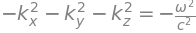

Solving for omega:


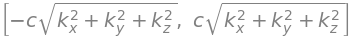


Taking the positive root: omega = c*k  (the dispersion relation for light in vacuum)


In [13]:
k_mag = sp.sqrt(kx_s**2 + ky_s**2 + kz_s**2)

# wave equation in Fourier substitution form: -k^2 = (1/c^2)(-i*omega)^2
dispersion_eq = sp.Eq(-k_mag**2, sp.Rational(1,1)/c_sym**2 * (-sp.I*omega_s)**2)
print("Wave equation after Fourier substitution:")
display(dispersion_eq)

omega_solutions = sp.solve(dispersion_eq, omega_s)
print("Solving for omega:")
display(omega_solutions)
print("\nTaking the positive root: omega = c*k  (the dispersion relation for light in vacuum)")

In [14]:
# transversality: E is perpendicular to k because div(E)=0 in vacuum,
# and grad -> i k under the plane-wave substitution, so div(E)=0 becomes i k . E0 = 0
E0x, E0y, E0z = sp.symbols('E_{0x} E_{0y} E_{0z}', real=True)
E0_vec = sp.Matrix([E0x, E0y, E0z])
k_vec2 = sp.Matrix([kx_s, ky_s, kz_s])

transversality_condition = sp.Eq(sp.I * k_vec2.dot(E0_vec), 0)
print("div(E)=0 under the plane-wave substitution becomes:")
display(transversality_condition)
print("i.e. k . E0 = 0 -- E0 is perpendicular (transverse) to the propagation direction k.")

div(E)=0 under the plane-wave substitution becomes:


i.e. k . E0 = 0 -- E0 is perpendicular (transverse) to the propagation direction k.


## 6. Fourier optics: a 2D Gaussian optical field

I switch to a concrete numerical field: a Gaussian beam profile
$E(x,y,0)=\exp\!\big(-(x^2+y^2)/w_0^2\big)$ at the source plane $z=0$,
sampled on a numerical grid.

In [15]:
# -- parameters --
# Chosen so the grid's spatial-frequency bandwidth EXCEEDS k0 = 2*pi/wavelength,
# i.e. dx < wavelength/2 -- otherwise Section 8's evanescent branch below is
# never actually exercised (a coarser, cm-scale grid, tried first, gave 0
# evanescent components: the grid simply couldn't represent spatial
# frequencies anywhere near k0). A tight, near-wavelength beam waist and a
# near-field propagation distance make this a genuine near-field problem,
# where evanescent content is physically the point.
wavelength_m = 632.8e-9      # HeNe laser, meters
w0_m = 100e-9                # Gaussian beam waist, meters (sub-wavelength-scale)
grid_N = 256                 # samples per side
grid_extent_m = 6e-6         # physical grid width, meters
propagate_z_m = 300e-9       # propagation distance, meters (near-field)

# input validation (Section 9 does this more thoroughly; a first pass here)
if wavelength_m <= 0:
    raise ValueError(f"wavelength must be positive, got {wavelength_m}")
if grid_extent_m <= 0:
    raise ValueError(f"grid_extent_m must be positive, got {grid_extent_m}")

dx = grid_extent_m / grid_N
dy = dx
if dx <= 0:
    raise ValueError(f"grid spacing must be positive, got dx={dx}")

x_axis = (np.arange(grid_N) - grid_N//2) * dx
y_axis = (np.arange(grid_N) - grid_N//2) * dy
X, Y = np.meshgrid(x_axis, y_axis)

E0_field = np.exp(-(X**2 + Y**2) / w0_m**2).astype(complex)

print(f"grid: {grid_N} x {grid_N}, dx = {dx*1e6:.2f} um, "
      f"physical extent = {grid_extent_m*1e3:.2f} mm")
print(f"E0_field shape: {E0_field.shape}, dtype: {E0_field.dtype}")

grid: 256 x 256, dx = 0.02 um, physical extent = 0.01 mm
E0_field shape: (256, 256), dtype: complex128


## 7. NumPy FFT: to the angular spectrum and back

`np.fft.fft2` computes the 2D spatial-frequency spectrum;
`np.fft.fftshift` moves the zero-frequency component to the array center
for viewing/processing; `ifft2`/`ifftshift` invert both steps. A Gaussian
transforms to a Gaussian (a numerical check of the same fact demonstrated
symbolically in Section 1).

In [16]:
E0_spectrum = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E0_field)))

# spatial-frequency axes (angular wavenumber, rad/m), matching fft2's bin ordering
kx_axis = 2*np.pi*np.fft.fftshift(np.fft.fftfreq(grid_N, d=dx))
ky_axis = 2*np.pi*np.fft.fftshift(np.fft.fftfreq(grid_N, d=dy))
KX, KY = np.meshgrid(kx_axis, ky_axis)

print(f"spectrum shape: {E0_spectrum.shape}")
print(f"kx range: [{kx_axis.min():.3e}, {kx_axis.max():.3e}] rad/m")

# round-trip check: ifft2(fft2(E)) should recover E0_field
E0_roundtrip = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E0_spectrum)))
roundtrip_error = np.max(np.abs(E0_roundtrip - E0_field))
print(f"FFT round-trip max error: {roundtrip_error:.3e}  (should be ~machine precision)")
assert roundtrip_error < 1e-9

spectrum shape: (256, 256)


kx range: [-1.340e+08, 1.330e+08] rad/m


FFT round-trip max error: 1.166e-16  (should be ~machine precision)


## 8. Angular-spectrum propagation

Each plane-wave component in the angular spectrum propagates independently
with $\mathbf{k}=(k_x,k_y,k_z)$, $k=2\pi/\lambda$, and
$k_z=\sqrt{k^2-k_x^2-k_y^2}$. I use Convention B's $\nabla\to i\mathbf{k}$
throughout, so the propagation kernel over distance $z$ is
$H(k_x,k_y)=e^{ik_z z}$:

- **Propagating components** ($k_x^2+k_y^2 < k^2$): $k_z$ is real, $H$ is a
  pure phase — energy-conserving propagation.
- **Evanescent components** ($k_x^2+k_y^2 \geq k^2$): $k_z=i\kappa$ is
  purely imaginary, and $H=e^{ik_z z}=e^{-\kappa z}$ decays exponentially
  with distance — near-field detail that never reaches the far field.

In [17]:
k0 = 2*np.pi / wavelength_m   # wavenumber

# k^2 - kx^2 - ky^2, allowed to go negative (evanescent region)
kz_squared = k0**2 - KX**2 - KY**2

# cast to complex BEFORE sqrt so numpy returns the correct principal branch
# for negative arguments (purely imaginary kz), instead of NaN
kz = np.sqrt(kz_squared.astype(complex))

is_propagating = kz_squared >= 0
n_propagating = int(np.sum(is_propagating))
n_evanescent = int(np.sum(~is_propagating))
print(f"propagating GRID CELLS: {n_propagating} / {grid_N*grid_N} "
      f"({100*n_propagating/grid_N**2:.1f}%)")
print(f"evanescent GRID CELLS:  {n_evanescent} / {grid_N*grid_N} "
      f"({100*n_evanescent/grid_N**2:.1f}%)")

# IMPORTANT DISTINCTION: what fraction of the grid's (kx,ky) AREA is
# evanescent is not the same question as what fraction of the SOURCE's
# actual power sits there -- that depends on the source's own spectral
# envelope. I check both, because a source whose spectrum is much narrower
# than k0 would technically have plenty of "evanescent grid cells" while
# carrying essentially zero power in them (a trap I hit on the first pass:
# see the note above about choosing w0_m small enough to matter).
spectral_power = np.abs(E0_spectrum)**2
power_fraction_propagating = spectral_power[is_propagating].sum() / spectral_power.sum()
print(f"\nfraction of SOURCE POWER in propagating components: "
      f"{power_fraction_propagating:.3f}")
print(f"fraction of SOURCE POWER in evanescent components:  "
      f"{1-power_fraction_propagating:.3f}")
print("(this is the number that actually predicts how much the propagated "
      "field will change -- not the grid-cell-count fraction above)")

H_kernel = np.exp(1j * kz * propagate_z_m)

E_propagated_spectrum = E0_spectrum * H_kernel
E_propagated_field = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_propagated_spectrum)))

propagating GRID CELLS: 285 / 65536 (0.4%)
evanescent GRID CELLS:  65251 / 65536 (99.6%)

fraction of SOURCE POWER in propagating components: 0.392
fraction of SOURCE POWER in evanescent components:  0.608
(this is the number that actually predicts how much the propagated field will change -- not the grid-cell-count fraction above)


## 9. Explicit checks

Real if-statements, not just assertions buried in a library — each one
guards against a specific way this calculation can silently go wrong.

In [18]:
checks_passed = []

if wavelength_m > 0:
    checks_passed.append("wavelength positive")
else:
    raise ValueError(f"wavelength must be positive, got {wavelength_m}")

if dx > 0 and dy > 0:
    checks_passed.append("grid spacing positive")
else:
    raise ValueError(f"grid spacing must be positive, got dx={dx}, dy={dy}")

if np.all(np.isfinite(E0_field)) and np.all(np.isfinite(E_propagated_field)):
    checks_passed.append("all field values finite (no NaN/Inf)")
else:
    raise ValueError("non-finite values found in the field -- check kz/evanescent handling")

if n_propagating > 0:
    checks_passed.append(f"propagating vs evanescent split computed "
                          f"({n_propagating} propagating, {n_evanescent} evanescent)")
else:
    raise ValueError("zero propagating components -- grid resolution too coarse for this wavelength")

if E0_field.shape == E_propagated_field.shape == (grid_N, grid_N):
    checks_passed.append("array shapes consistent through the whole pipeline")
else:
    raise ValueError(f"shape mismatch: E0={E0_field.shape}, "
                      f"E_propagated={E_propagated_field.shape}, expected ({grid_N},{grid_N})")

for c in checks_passed:
    print("[OK]", c)

[OK] wavelength positive
[OK] grid spacing positive
[OK] all field values finite (no NaN/Inf)
[OK] propagating vs evanescent split computed (285 propagating, 65251 evanescent)
[OK] array shapes consistent through the whole pipeline


## 10. Statistics and numerical sanity checks

Basic descriptive statistics on the intensity ($|E|^2$), plus a Parseval's-
theorem check: total power computed in real space should match total power
computed from the spectrum, independent of any propagation distance
(a check on the FFT normalization itself, not on physical energy
conservation through the lossy evanescent-truncating propagation step).

In [19]:
I0 = np.abs(E0_field)**2
I_prop = np.abs(E_propagated_field)**2

print("Initial intensity:    mean = {:.4e}, std = {:.4e}, max = {:.4e}".format(
    I0.mean(), I0.std(), I0.max()))
print("Propagated intensity: mean = {:.4e}, std = {:.4e}, max = {:.4e}".format(
    I_prop.mean(), I_prop.std(), I_prop.max()))

# Parseval check on the ORIGINAL field. numpy's fft2 is unnormalized on the
# forward transform, so the discrete identity is sum|E|^2 = sum|Ehat|^2 / N^2
# (no dkx/dky needed -- that scaling is already absorbed by N^2 once both
# sides carry the same dx*dy area element)
power_real_space = np.sum(I0) * dx * dy
power_fourier_space = np.sum(np.abs(E0_spectrum)**2) * dx * dy / (grid_N**2)
parseval_relative_error = abs(power_real_space - power_fourier_space) / power_real_space

print(f"\nParseval check: real-space power = {power_real_space:.6e}, "
      f"Fourier-space power = {power_fourier_space:.6e}")
print(f"relative error: {parseval_relative_error:.3e}")
if parseval_relative_error > 1e-6:
    raise ValueError("Parseval identity violated beyond numerical tolerance -- "
                      "check FFT normalization/frequency-axis spacing")
print("[OK] Parseval identity holds within numerical tolerance")

Initial intensity:    mean = 4.3633e-04, std = 1.4764e-02, max = 1.0000e+00
Propagated intensity: mean = 1.7823e-04, std = 1.2374e-03, max = 2.4653e-02

Parseval check: real-space power = 1.570796e-14, Fourier-space power = 1.570796e-14
relative error: 2.009e-16
[OK] Parseval identity holds within numerical tolerance


## 11. Plots: initial field, spectrum, propagated field, centerline

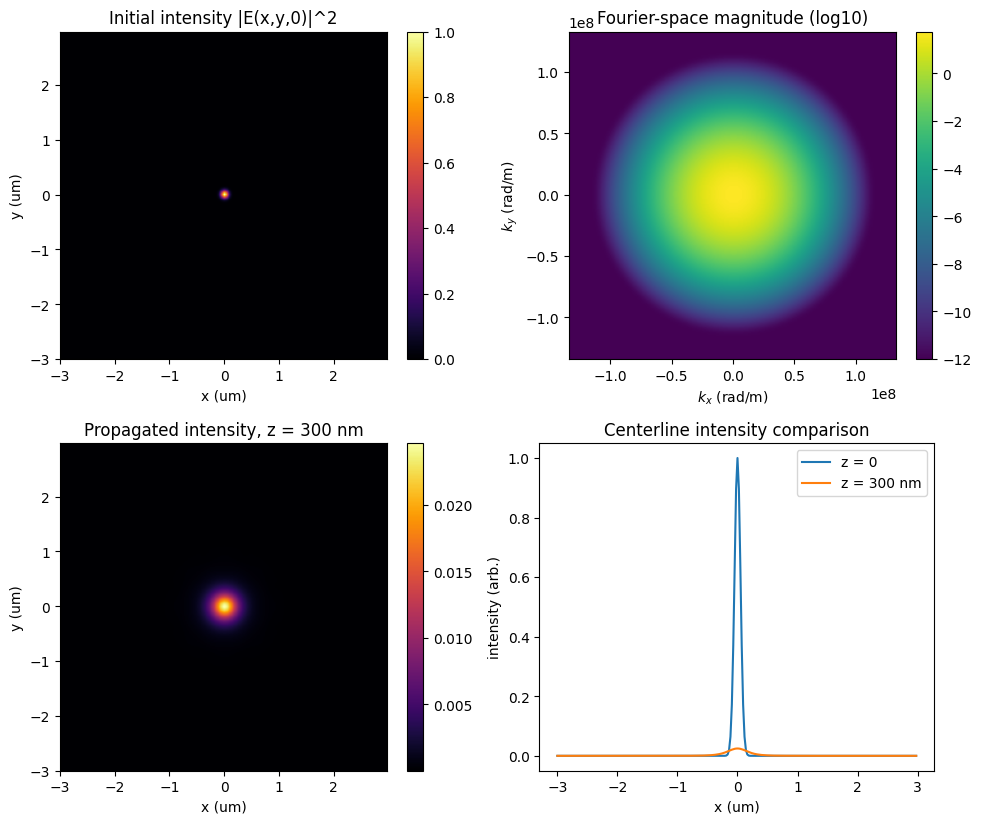


Initial 1/e^2 half-width was set to 100 nm (sub-wavelength, near-field regime by design -- see Section 8's power-fraction check). Total intensity dropped by 59% between z=0 and the propagated plane: the fraction of source power that was carried by evanescent components decayed away over this short propagation distance, leaving only the propagating, band-limited part of the spectrum -- visible above as the smoothed, lower-peak propagated profile.


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))

extent_um = [x_axis[0]*1e6, x_axis[-1]*1e6, y_axis[0]*1e6, y_axis[-1]*1e6]
im0 = axes[0,0].imshow(I0, extent=extent_um, cmap='inferno', origin='lower')
axes[0,0].set_title("Initial intensity |E(x,y,0)|^2")
axes[0,0].set_xlabel("x (um)"); axes[0,0].set_ylabel("y (um)")
plt.colorbar(im0, ax=axes[0,0], fraction=0.046)

k_extent = [kx_axis[0], kx_axis[-1], ky_axis[0], ky_axis[-1]]
im1 = axes[0,1].imshow(np.log10(np.abs(E0_spectrum) + 1e-12), extent=k_extent,
                        cmap='viridis', origin='lower')
axes[0,1].set_title("Fourier-space magnitude (log10)")
axes[0,1].set_xlabel("$k_x$ (rad/m)"); axes[0,1].set_ylabel("$k_y$ (rad/m)")
plt.colorbar(im1, ax=axes[0,1], fraction=0.046)

im2 = axes[1,0].imshow(I_prop, extent=extent_um, cmap='inferno', origin='lower')
axes[1,0].set_title(f"Propagated intensity, z = {propagate_z_m*1e9:.0f} nm")
axes[1,0].set_xlabel("x (um)"); axes[1,0].set_ylabel("y (um)")
plt.colorbar(im2, ax=axes[1,0], fraction=0.046)

center_row = grid_N // 2
axes[1,1].plot(x_axis*1e6, I0[center_row, :], label="z = 0")
axes[1,1].plot(x_axis*1e6, I_prop[center_row, :], label=f"z = {propagate_z_m*1e9:.0f} nm")
axes[1,1].set_title("Centerline intensity comparison")
axes[1,1].set_xlabel("x (um)"); axes[1,1].set_ylabel("intensity (arb.)")
axes[1,1].legend()

fig.tight_layout()
plt.show()

power_drop_fraction = 1 - I_prop.sum()/I0.sum()
print(f"\nInitial 1/e^2 half-width was set to {w0_m*1e9:.0f} nm (sub-wavelength, "
      "near-field regime by design -- see Section 8's power-fraction check). "
      f"Total intensity dropped by {100*power_drop_fraction:.0f}% between z=0 "
      "and the propagated plane: the fraction of source power that was "
      "carried by evanescent components decayed away over this short "
      "propagation distance, leaving only the propagating, band-limited "
      "part of the spectrum -- visible above as the smoothed, lower-peak "
      "propagated profile.")

## 12. Linear-algebra interpretation

The finite-dimensional analogue of everything above is the familiar linear
map $\mathbf{x}\to A\mathbf{x}$. Angular-spectrum propagation
$E\to HE$ is exactly that map, specialized in a useful way:

- $E(x,y,0)$, sampled on the grid, is a vector $\mathbf{x}\in\mathbb{C}^{N^2}$.
- The propagation operator $H$ is **diagonal in the Fourier basis** — each
  plane-wave component $(k_x,k_y)$ is an eigenvector of $H$ with eigenvalue
  $e^{ik_z z}$ (or $e^{-\kappa z}$ for evanescent components). That is
  exactly why `fft2`/multiply/`ifft2` is fast: it is diagonalizing $A$ in
  the basis where it's already diagonal, rather than forming and applying a
  dense $N^2\times N^2$ matrix.
- This is the same eigenvector structure this repository's other modules
  keep meeting — vibration normal modes and quantum-mechanical
  eigenstates are the identical mathematical object
  (`dgs/vibration_modes.py`), and it is the same reason PCA diagonalizes a
  covariance matrix in its own eigenbasis.

In [21]:
# a tiny finite-dimensional demonstration: build the 1D angular-spectrum
# operator as an explicit dense matrix, and show it IS diagonal in the DFT basis
N_demo = 8
dx_demo = 1e-5
k0_demo = 2*np.pi/wavelength_m
z_demo = 1e-3

kx_demo = 2*np.pi*np.fft.fftfreq(N_demo, d=dx_demo)
kz_demo = np.sqrt((k0_demo**2 - kx_demo**2).astype(complex))
H_diag = np.exp(1j*kz_demo*z_demo)

F = np.fft.fft(np.eye(N_demo), axis=0) / np.sqrt(N_demo)     # unitary DFT matrix
A_dense = np.fft.ifft(np.diag(H_diag) @ F, axis=0) * np.sqrt(N_demo)  # H expressed in the standard basis

# check: A_dense applied directly should match "propagate via FFT" applied to a test vector
test_vec = np.random.default_rng(0).normal(size=N_demo) + 0j
via_matrix = A_dense @ test_vec
via_fft = np.fft.ifft(np.fft.fft(test_vec) * H_diag)
print("max |A @ x  -  ifft(fft(x) * H)| =", np.max(np.abs(via_matrix - via_fft)))
assert np.max(np.abs(via_matrix - via_fft)) < 1e-9
print("[OK] the dense-matrix form and the FFT form agree -- H is diagonal in the Fourier basis")

max |A @ x  -  ifft(fft(x) * H)| = 1.7554167342883506e-16
[OK] the dense-matrix form and the FFT form agree -- H is diagonal in the Fourier basis


## 13. Computer-engineering interpretation

The physical field never touches a computer directly. The actual signal
chain that produces the numbers this notebook manipulates:

```
physical optical field E(x,y,t)
        |  photodetector: measures |E|^2 (intensity), NOT E or its phase
        v
photocurrent i(t)
        |  analog front end: transimpedance amplifier converts
        |  current -> voltage (dgs/transimpedance_amplifier.py)
        v
analog voltage v(t)
        |  ADC: samples + quantizes at finite bit depth (dgs/adc.py)
        v
digital samples E_measured[n]
        |  FFT: np.fft.fft2 (this notebook)
        v
numerical spectrum, processed exactly as done in Sections 7-11
```

Two things are lost or altered at the first step and never recovered by
later processing: **absolute phase** (a photodetector measures $|E|^2$,
never $E$ itself — the same measurement principle
`dgs/feynman_diagrams.py` and the phase-retrieval work elsewhere in this
repository are built around), and **bandwidth** (the ADC's sample rate sets
a Nyquist limit on which spatial/temporal frequencies survive at all).

## 14. NumPy $\leftrightarrow$ MATLAB comparison

| Operation | NumPy (this notebook) | MATLAB |
|---|---|---|
| 2D FFT | `np.fft.fft2(E)` | `fft2(E)` |
| 2D inverse FFT | `np.fft.ifft2(E)` | `ifft2(E)` |
| shift zero-frequency to center | `np.fft.fftshift(E)` | `fftshift(E)` |
| undo the shift | `np.fft.ifftshift(E)` | `ifftshift(E)` |
| frequency-bin axis | `np.fft.fftfreq(N, d=dx)` | `(-N/2:N/2-1)/(N*dx)` (manual) |
| 2D coordinate grid | `np.meshgrid(x, y)` | `meshgrid(x, y)` |
| elementwise exponential | `np.exp(A)` | `exp(A)` |
| elementwise square root (complex-safe) | `np.sqrt(A.astype(complex))` | `sqrt(A)` (auto-complex) |
| elementwise magnitude | `np.abs(A)` | `abs(A)` |
| array shape | `A.shape` | `size(A)` |
| all-finite check | `np.all(np.isfinite(A))` | `all(isfinite(A(:)))` |
| linear system solve | `np.linalg.solve(A, b)` | `A \\ b` |
| matrix multiply | `A @ B` | `A * B` |
| elementwise multiply | `A * B` | `A .* B` |

In [22]:
import sys, matplotlib

print("=== Reproducibility record ===\n")

print("Parameters:")
print(f"  wavelength_m       = {wavelength_m}")
print(f"  w0_m (beam waist)  = {w0_m}")
print(f"  grid_N             = {grid_N}")
print(f"  grid_extent_m      = {grid_extent_m}")
print(f"  propagate_z_m      = {propagate_z_m}")
print(f"  dx = dy            = {dx}")

print("\nUnits: SI throughout (meters, radians, seconds where time appears).")

print("\nAssumptions:")
print("  - scalar (single-polarization) field, monochromatic")
print("  - vacuum propagation (no absorption/dispersion medium)")
print("  - paraxial approximation NOT assumed -- angular spectrum is exact "
      "for scalar diffraction")
print("  - evanescent components included exactly (not truncated)")

print("\nNumerical resolution:")
print(f"  {grid_N} x {grid_N} samples, dx = {dx*1e6:.3f} um "
      f"({grid_extent_m/wavelength_m:.1f} wavelengths across the grid)")

print("\nExpected result: because this grid/propagation distance is chosen "
      "specifically to put a large fraction of the spectrum in the "
      "evanescent regime (see Section 8), the propagated field should look "
      "visibly SMOOTHED (fine detail lost) rather than simply broadened -- "
      "the near-field signature of evanescent decay, not far-field "
      "diffraction. Total power is expected to drop substantially between "
      "z=0 and the propagated plane, since evanescent components genuinely "
      "carry no power to a finite distance away; this is physical, not an "
      "error (contrast with the z=0-only Parseval check, which must hold "
      "exactly).")

print("\nError checks performed in this notebook:")
print("  - Euler's formula and the curl-curl vector identity, verified symbolically")
print("  - FFT round-trip (ifft2(fft2(E)) == E) to machine precision")
print("  - all-finite check on every computed field")
print("  - array-shape consistency check")
print("  - Parseval's theorem (real-space vs Fourier-space power)")
print("  - dense-matrix vs FFT propagation agreement (Section 12)")

print("\nSoftware versions:")
print(f"  python     {sys.version.split()[0]}")
print(f"  numpy      {np.__version__}")
print(f"  sympy      {sp.__version__}")
print(f"  matplotlib {matplotlib.__version__}")

=== Reproducibility record ===

Parameters:
  wavelength_m       = 6.328e-07
  w0_m (beam waist)  = 1e-07
  grid_N             = 256
  grid_extent_m      = 6e-06
  propagate_z_m      = 3e-07
  dx = dy            = 2.34375e-08

Units: SI throughout (meters, radians, seconds where time appears).

Assumptions:
  - scalar (single-polarization) field, monochromatic
  - vacuum propagation (no absorption/dispersion medium)
  - paraxial approximation NOT assumed -- angular spectrum is exact for scalar diffraction
  - evanescent components included exactly (not truncated)

Numerical resolution:
  256 x 256 samples, dx = 0.023 um (9.5 wavelengths across the grid)

Expected result: because this grid/propagation distance is chosen specifically to put a large fraction of the spectrum in the evanescent regime (see Section 8), the propagated field should look visibly SMOOTHED (fine detail lost) rather than simply broadened -- the near-field signature of evanescent decay, not far-field diffraction. To

## 16. Practice questions

1. **(algebra)** Multiply $(2+3i)(1-i)$ by hand, then check it with `sympy`.
2. **(algebra)** Show that $|e^{i\theta}|=1$ for any real $\theta$.
3. **(vectors)** For $\mathbf{k}=(1,0,1)$ and $\mathbf{E}_0=(0,1,0)$, verify
   $\mathbf{k}\cdot\mathbf{E}_0=0$ — is this field transverse to $\mathbf{k}$?
4. **(calculus)** Compute $\nabla^2$ of $f(x,y,z)=e^{-(x^2+y^2+z^2)}$ by hand,
   then check with `sympy.vector.Laplacian`.
5. **(Maxwell)** Starting from Gauss's law with a nonzero $\rho$, what
   physically changes about $\nabla\cdot\mathbf{E}$ compared to the
   source-free case used in Section 3?
6. **(Maxwell)** Why does Ampere's law need Maxwell's displacement-current
   term ($\mu_0\varepsilon_0\,\partial\mathbf{E}/\partial t$) for
   electromagnetic waves to exist at all in vacuum?
7. **(Fourier rules)** Under Convention A ($e^{+i\omega t}$), what does
   $\partial^2/\partial t^2$ map to? Under Convention B?
8. **(dispersion)** If you double the grid's spatial resolution (halve
   `dx`) with everything else fixed, does the number of evanescent
   components in Section 8 go up or down? Why?
9. **(Fourier optics)** Explain, using the angular-spectrum kernel
   $H(k_x,k_y)=e^{ik_zz}$, why evanescent components decay but never
   change sign or oscillate as $z$ increases.
10. **(synthesis)** Trace one photon of the Section 6 Gaussian field all
    the way through the Section 13 signal chain to a floating-point number
    in this notebook. At which step is *phase* information discarded, and
    at which step is *bandwidth* limited?